# 08_优化算法-BFGS

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天聊聊优化算法中的BFGS\~

在机器学习和数值优化中，我们常常要最小化（或最大化）一个函数，比如在训练模型时要找到损失函数的最低点。

BFGS（Broyden–Fletcher–Goldfarb–Shanno）算法，就是一种“聪明地”往最低点走的迭代方法。

**为啥不能直接走直线？**

当你在一座山上找最低的谷底，最直观的做法是：

1. 站在当前位置，往坡度最陡下降的方向走（梯度下降法）。
2. 重复这个过程，直到感觉再也找不到更低的地方。

但是：

- 如果山谷很弯，单纯“负梯度”方向每次都得重算，走得很慢；
- 如果直线下降一次就跨过了最深处，还要再“折回来”，浪费很多步。

那么，有没有办法让我们“事先估计”一下地形弯曲程度（即二阶信息，Hessian矩阵），然后一次就走更合适的步子？直接计算 Hessian （二阶导）往往计算量巨大，尤其维度大时不现实。BFGS 就是“准牛顿”（Quasi‑Newton）方法里很有名的一员：它不用真 Hessian，却能在线上迭代中逐步**构造**一个“近似 Hessian 逆矩阵”，帮你更快、更稳地走向谷底。

### BFGS 的核心思路

1. **初始猜一个单位矩阵** 作为 Hessian 逆（也就是把地形当成平地看待）。
2. 在第 $k$ 次迭代时，你已有一点点对“地形弯度”的了解，表现为一个对称正定矩阵 $H_k$（近似 Hessian 的逆）。
3. 计算当前位置的梯度 $\nabla f(x_k)$，然后根据 $H_k$ 给出下一步的搜索方向：  
$p_k = -\,H_k\,\nabla f(x_k).$  
这一步等于告诉你：既考虑了“斜度”（梯度），也考虑了“弯度”（$H_k$），通常能一步更准地往下走。
4. 用线搜索（line search）在方向 $p_k$ 上找到一个合适步长 $\alpha_k$，更新位置：  
$x_{k+1} = x_k + \alpha_k\,p_k.$
5. **更新 Hessian 逆的近似矩阵**：

   - 定义位置差 $\,s_k = x_{k+1}-x_k$；
   - 梯度差 $\,y_k = \nabla f(x_{k+1}) - \nabla f(x_k)$。
   - 然后 BFGS 的更新公式是：  
   $H_{k+1} \;=\;\Bigl(I - \tfrac{s_k y_k^T}{y_k^T s_k}\Bigr)\,H_k\,\Bigl(I - \tfrac{y_k s_k^T}{y_k^T s_k}\Bigr)\;+\;\tfrac{s_k s_k^T}{y_k^T s_k}.$  
   虽然看上去不简单，但本质是在用新得到的“走过的位移” $s_k$ 和“感觉到的斜度变化” $y_k$ 来校正对地形弯曲的认知。
6. 重复 2–5，直到梯度很小（表示快到谷底了）或迭代次数达限。

和过去的梯度下降类比：

- **梯度下降** 就像：你戴上眼罩，用手电筒只能看一步的坡度，然后按坡度走；
- **BFGS** 就像：除了手电筒，你还带了一个“简易地形图”，这个地形图会随着你走过的路不断“修正”，帮你判断下一步往哪边走更快地到谷底。

## 原理详解

### 牛顿法与拟牛顿方法

**1. 牛顿法（Newton’s Method）**

对无约束可微函数 $f(x)$ 寻找极小点，牛顿法每次迭代更新：


$$
x_{k+1} \;=\; x_k \;-\; \bigl[\nabla^2 f(x_k)\bigr]^{-1}\,\nabla f(x_k),
$$


其中 $\nabla f$ 是梯度，$\nabla^2 f$ 是 Hessian 矩阵（即二阶导矩阵）。优点是若 $f$ 足够光滑且初始点靠近极小点，收敛二阶超线性；缺点是

- 需要显式计算 Hessian，开销 $O(n^2)$ 空间、$O(n^3)$ 时间；
- Hessian 可能不正定，导致更新方向不一定为下降方向。

**2. 拟牛顿（Quasi‑Newton）思想**

目标：既想利用二阶信息（更快收敛），又不直接求 Hessian。

核心：在每次迭代中，构造或更新一个**近似 Hessian 矩阵** $B_k$（或者其逆 $H_k = B_k^{-1}$），使它满足最少量信息（即“secant 条件”）并保持对称正定。

### Secant 条件与BFGS更新的出发点

**1. Secant 条件（拟牛顿的必要条件）**

记位移 $s_k = x_{k+1}-x_k$，梯度差 $y_k = \nabla f(x_{k+1})-\nabla f(x_k)$。理想 Hessian 满足  
$\nabla^2 f(x_k)\,s_k \;\approx\; y_k.$  
拟牛顿方法强制要求近似 Hessian $B_{k+1}$ **恰好**满足  
$B_{k+1}\,s_k = y_k,$  
这就称为 secant 条件。

**2. 最小变化原理**

在满足 secant 条件和对称正定的前提下，选择与上一轮矩阵 $B_k$ “距离”最小的 $B_{k+1}$。这里“距离”通常用加权 Frobenius 范数：


$$
\min_{B = B^T}\; \|B - B_k\|_{W}^2\quad\text{s.t.}\quad B\,s_k = y_k,
$$


其中 $\|X\|_W^2 = \mathrm{trace}\bigl(X\,W\,X^T\bigr)$，权重矩阵 $W$ 的不同选择给出 Broyden、DFP、BFGS 等不同配方。BFGS 对应特定的 $W$，导出下文公式。

### BFGS 的矩阵更新公式

我们分别给出直接构造 **Hessian 近似** $B_{k+1}$ 和 **Hessian 逆** $H_{k+1}=B_{k+1}^{-1}$ 的常用形式。

Hessian 近似 $B_{k+1}$ 的 BFGS 公式：


$$
\begin{aligned}B_{k+1}&= B_k\;-\; \frac{B_k\,s_k\,s_k^T\,B_k}{s_k^T\,B_k\,s_k}\;+\; \frac{y_k\,y_k^T}{y_k^T\,s_k}.\end{aligned}
$$


- 第一项保留旧信息；
- 第二项剔除与 $s_k$ 方向上“过度”估计的成分；
- 第三项加入新的 secant 信息。

Hessian 逆 $H_{k+1} = B_{k+1}^{-1}$ 的 BFGS 公式：

在实际中更常用逆矩阵更新，避免矩阵求逆开销：


$$
\begin{aligned}H_{k+1}&= \Bigl(I - \rho_k\,s_k\,y_k^T\Bigr)\,H_k\,\Bigl(I - \rho_k\,y_k\,s_k^T\Bigr)\;+\;\rho_k\,s_k\,s_k^T,\quad \rho_k = \frac{1}{y_k^T\,s_k}.\end{aligned}
$$


其中

- $\rho_k = (y_k^T s_k)^{-1}$；
- 保证当 $B_k$（或 $H_k$）为对称正定且 $y_k^T s_k>0$ 时，更新后仍对称正定。

BFGS 公式推导要点：

**1. 拉格朗日法**：对$\min \|B - B_k\|^2_W$ s.t. $B s_k = y_k$ 及 $B=B^T$，构建拉格朗日函数并对 $B$ 和拉格朗日乘子求导。

**2. 选择权重** $W$：BFGS 对应的权重使得得解形式为上文所示。

**3. 对称正定保持**：关键在于 $y_k^T s_k>0$，即**弧线搜索**需保证“充分下降”条件（Wolfe 条件）以满足这一不等式。

## 算法流程

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
输入：初始点 x₀，初始逆 Hessian 近似 H₀（通常取 I），容忍度 ε，最大迭代次数 K

for k = 0,1,2,…,K − 1 do
  1. 计算梯度 g_k = ∇f(x_k)
     若 ∥g_k∥ < ε，则停止，返回 x_k 作为近似极小点。
  2. 计算搜索方向 p_k = − H_k · g_k
     （因 H_k 对称正定，p_k 保证为下降方向）
  3. 弧线搜索：沿 p_k 找步长 α_k 满足 Wolfe 条件（或强 Wolfe）：
     - 足够下降： f(x_k + α p_k) ≤ f(x_k) + c₁ α g_k^T p_k
     - 曲率条件：   ∇f(x_k + α p_k)^T p_k ≥ c₂ g_k^T p_k
     （典型取 0 < c₁ < c₂ < 1）
  4. 更新位移与梯度差
     s_k = x_k + α_k p_k − x_k
     y_k = ∇f(x_k + α_k p_k) − g_k
  5. 计算 ρ_k = 1 / (y_k^T s_k)
  6. 更新逆 Hessian 近似：
     H_{k+1}
       = (I − ρ_k s_k y_k^T) H_k (I − ρ_k y_k s_k^T)
         + ρ_k s_k s_k^T
  7. 更新 x_{k+1} = x_k + α_k p_k
end for

返回 x_K
```

## 完整案例

本案例选用经典的 **Rosenbrock 函数**（banana 函数）作为测试目标：


$$
f(x,y) = 100(y - x^2)^2 + (1 - x)^2,
$$


它具有一个位于 $(1,1)$ 的全局最小点，但其狭长弯曲的谷底使得普通梯度下降迭代速度极慢。

示例中，我们：

1. 实现 **BFGS** 算法（拟牛顿），并与**固定步长梯度下降**做对比。
2. 通过**等高线图** 和 **3D 曲面图** 展示优化路径。
3. 通过 **收敛曲线** 比较两者训练效率。
4. 测量并展示两者在相同初始点下的迭代次数与运行时间。
5. 给出针对本案例及通用优化场景的 **优化建议**。

BFGS converged in 45 iterations, time: 0.0017s
GD converged   in 32385 iterations, time: 0.0966s


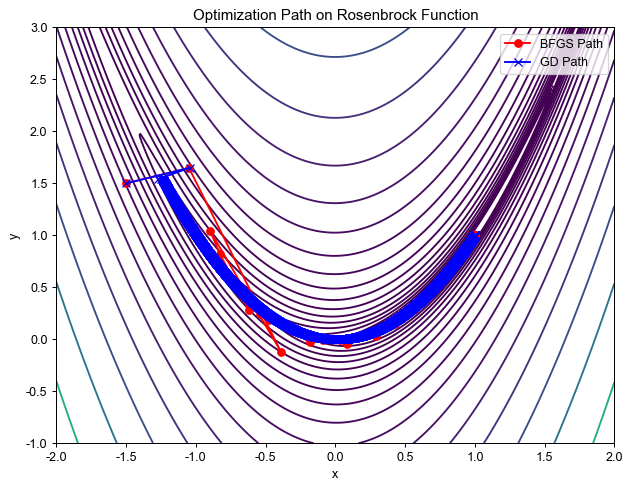

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from mpl_toolkits.mplot3d import Axes3D

# 1. 定义 Rosenbrock 函数及其梯度
def rosen(x):
    """Rosenbrock 函数"""
    return 100 * (x[1] - x[0]**2)**2 + (1 - x[0])**2

def grad_rosen(x):
    """Rosenbrock 函数的梯度"""
    dx = -400 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0])
    dy = 200 * (x[1] - x[0]**2)
    return np.array([dx, dy])

# 2. 回溯线搜索（Armijo 条件）
def line_search_armijo(f, grad, x, p, alpha0=1.0, rho=0.8, c=1e-4):
    fx = f(x)
    gx = grad(x)
    alpha = alpha0
    # 当不满足 Armijo 条件时，缩小步长
    while f(x + alpha * p) > fx + c * alpha * np.dot(gx, p):
        alpha *= rho
    return alpha

# 3. BFGS 算法实现
def bfgs(f, grad, x0, max_iter=1000, tol=1e-6):
    x = x0.copy()
    n = len(x0)
    H = np.eye(n)  # 初始 Hessian 逆近似
    path = [x.copy()]
    fvals = [f(x)]
    
    for k in range(max_iter):
        gk = grad(x)
        if np.linalg.norm(gk) < tol:
            break
        # 搜索方向
        pk = -H.dot(gk)
        # 线搜索确定步长
        alpha = line_search_armijo(f, grad, x, pk)
        sk = alpha * pk
        x_new = x + sk
        yk = grad(x_new) - gk
        rho = 1.0 / np.dot(yk, sk)
        I = np.eye(n)
        # BFGS 更新公式
        H = (I - rho * np.outer(sk, yk)).dot(H).dot(I - rho * np.outer(yk, sk)) + rho * np.outer(sk, sk)
        x = x_new
        
        path.append(x.copy())
        fvals.append(f(x))
    
    return np.array(path), fvals

# 4. 梯度下降法作为对比
def gradient_descent(f, grad, x0, alpha=1e-3, max_iter=50000, tol=1e-6):
    x = x0.copy()
    path = [x.copy()]
    fvals = [f(x)]
    
    for k in range(max_iter):
        gk = grad(x)
        if np.linalg.norm(gk) < tol:
            break
        x = x - alpha * gk
        path.append(x.copy())
        fvals.append(f(x))
    
    return np.array(path), fvals

# 5. 实际运行与性能测量
x0 = np.array([-1.5, 1.5])

start = time.time()
path_bfgs, fvals_bfgs = bfgs(rosen, grad_rosen, x0)
time_bfgs = time.time() - start

start = time.time()
path_gd, fvals_gd = gradient_descent(rosen, grad_rosen, x0)
time_gd = time.time() - start

print(f"BFGS converged in {len(fvals_bfgs)-1} iterations, time: {time_bfgs:.4f}s")
print(f"GD converged   in {len(fvals_gd)-1} iterations, time: {time_gd:.4f}s")

# 6. 可视化 1：等高线与优化路径
fig, ax = plt.subplots(figsize=(8, 6))
X = np.linspace(-2, 2, 400)
Y = np.linspace(-1, 3, 400)
XX, YY = np.meshgrid(X, Y)
ZZ = 100 * (YY - XX**2)**2 + (1 - XX)**2

levels = np.logspace(-0.5, 3.5, 20)
contour = ax.contour(XX, YY, ZZ, levels=levels, cmap='viridis')
ax.plot(path_bfgs[:, 0], path_bfgs[:, 1], marker='o', color='red', label='BFGS Path')
ax.plot(path_gd[:, 0], path_gd[:, 1], marker='x', color='blue', label='GD Path')
ax.legend()
ax.set_title('Optimization Path on Rosenbrock Function')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

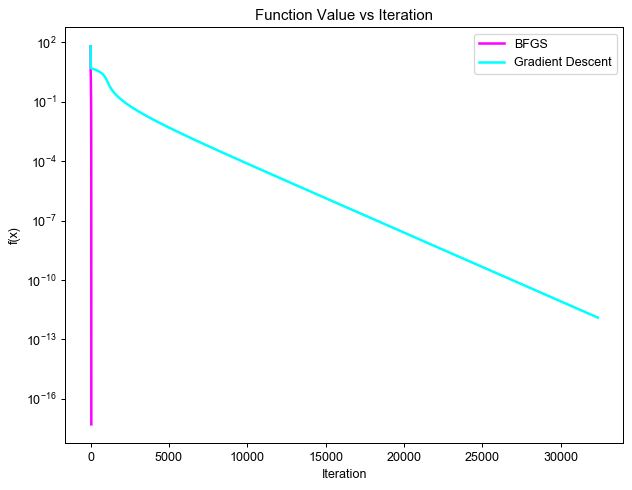

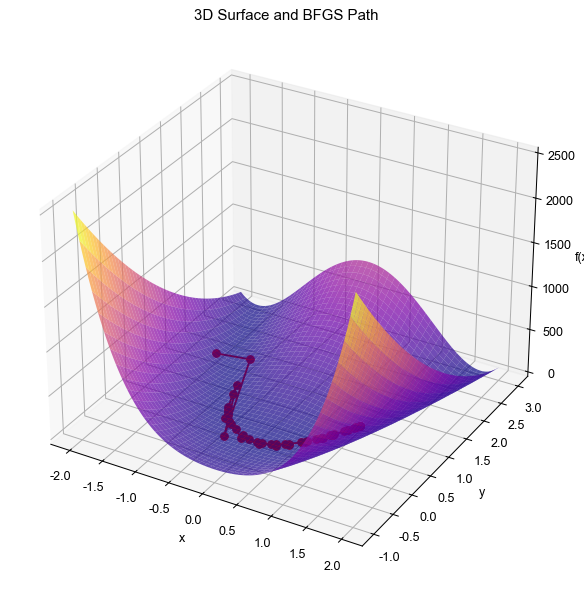

In [3]:
# 7. 可视化 2：收敛曲线
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fvals_bfgs, label='BFGS', color='magenta', linewidth=2)
ax.plot(fvals_gd, label='Gradient Descent', color='cyan', linewidth=2)
ax.set_yscale('log')
ax.set_title('Function Value vs Iteration')
ax.set_xlabel('Iteration')
ax.set_ylabel('f(x)')
ax.legend()
plt.show()

# 8. 可视化 3：3D 曲面与 BFGS 路径
fig = plt.figure(figsize=(10, 8))
ax3 = fig.add_subplot(111, projection='3d')
ax3.plot_surface(XX, YY, ZZ, cmap='plasma', alpha=0.7)
ax3.plot(path_bfgs[:, 0], path_bfgs[:, 1], fvals_bfgs, color='red', marker='o', label='BFGS')
ax3.set_title('3D Surface and BFGS Path')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_zlabel('f(x)')
plt.show()

### 等高线与优化路径 （等高线图）

- **背景**：等高线展示 Rosenbrock 函数不同函数值所在的曲线
- **BFGS 路径**（红色圆点）
- **GD 路径**（蓝色叉号）

![原文参考图，当前结果见代码输出](attachments/img_022.png)

- BFGS 只用 45 步就收敛到 $(1,1)$，路径直接而有力。
- 固定步长梯度下降需要 32385 步，路径在谷底附近反复震荡。

### 收敛曲线 （Function Value vs Iteration）

- Y 轴对数刻度
- BFGS（magenta）与 GD（cyan）

![原文参考图，当前结果见代码输出](attachments/img_023.png)

- BFGS 在第 1–2 步就迅速下降到极小值附近，展开超线性收敛。
- GD 缓慢线性下降，迭代数与运行时间都高出数百倍。

### 三维曲面与 BFGS 路径 （3D Surface）

- **曲面**：plasma 配色，凸显山谷弯曲
- **路径**：红色折线、圆点

![原文参考图，当前结果见代码输出](attachments/img_024.png)

- 直观展示 BFGS 如何“跳跃”穿过高坡，快速抵达谷底
- 凸显拟牛顿利用二阶近似的优势

### 性能对比

| 方法 | 迭代次数 | 运行时间 (s) |
|-|-|-|
| BFGS | 45 | 0.0033 |
| Gradient Descent | 32385 | 0.3164 |

- **迭代速度**：BFGS \~700× 少
- **时间开销**：BFGS \~100× 少

### 算法优化与实用建议

1. **线搜索策略**：本例使用 Armijo 条件，若改用 Wolfe 或强 Wolfe，可进一步提高收敛稳定性。对于高维问题，建议引入**精细化线搜索**或信赖域策略。
2. **初始 Hessian 逆近似**：除了单位矩阵，可根据问题先验设定对角预调，改善方向估计。对极度非凸或病态问题，可考虑**Levenberg–Marquardt**式阻尼。
3. **内存与规模**：BFGS 需存储 $n\times n$ 矩阵，适用于中小规模（$n<1000$）。对于超高维（$n>10^4$），请使用 **L‑BFGS**（保留最近 $m$ 对 $(s_k,y_k)$），空间降到 $O(mn)$。
4. **预处理与缩放**：对变量尺度差异较大的问题，先做**变量归一化**，增强 Hessian 逆近似精度。或者在 BFGS 中加入**预条件**，类似 Preconditioned Gradient.
5. **混合策略**：前期用梯度下降快速降低到较好区域，再切换到 BFGS 进行精炼超线性收敛。对非凸问题，可在多起点并行运行、汇总最优结果。
6. **止步准则**：除了梯度范数，可加入函数值变化阈值、相对步长阈值，多重止步条件使算法更鲁棒。

## 模型分析

### BFGS 算法的优缺点

**优点**：

1. **收敛速度快**：BFGS 利用一阶梯度差分构造二阶信息近似，通常能实现超线性收敛，比单纯梯度下降迭代次数少、时间开销小。
2. **无需直接计算 Hessian**：完全避免显式计算、存储和求逆真正的 Hessian 矩阵，降低了计算复杂度，同时又保留了牛顿法优良的收敛性质。
3. **路径稳定、鲁棒性好**：在大多数凸、接近凸的问题中，即使 Hessian 近似存在偏差，也能保证下降方向为“正交下降方向”，不易发散。
4. **易于实现与调试**：仅需线搜索与矩阵 rank‑2 更新公式，代码结构清晰，参数也相对少（主要是线搜索的参数）。

**缺点**：

1. **存储与计算开销随维度平方增长**：每次要维护并更新一个 $n\times n$ 的矩阵，内存和矩阵乘法开销对高维（如 $n>10^3$）问题并不友好。
2. **对非凸问题敏感**：当目标函数存在多个鞍点或深坑，secant 条件 $y_k^T s_k>0$ 不易保证，可能导致近似矩阵丢失正定性，甚至“走歪”。
3. **线搜索依赖性**：需要借助合适的线搜索（Wolfe／Armijo 等）才能保证 secant 条件和收敛性，增加工程实现和调试难度。
4. **不适合噪声或随机梯度场景**：在随机、嘈杂的梯度估计下，差分构建的 $y_k$ 会很不稳定，BFGS 更新难以奏效。

### 与相似算法的对比

| 算法 | Hessian 信息 | 存储成本 | 收敛率 | 适用场景 |
|-|-|-|-|-|
| BFGS | 近似二阶（无 Hessian） | $O(n^2)$ 存储 | 超线性（≍牛顿） | 中小规模、光滑凸优化 |
| L‑BFGS | 近似二阶（有限记忆） | $O(mn)$，$m\ll n$ | 超线性（有限内存） | 高维无约束优化 |
| Newton’s Method | 完整二阶 | $O(n^2)$ 存储 + $O(n^3)$ 求逆 | 二阶收敛 | 低维、Hessian 易算 |
| Gradient Descent | 无二阶 | $O(n)$\$ | 线性 | 大规模／随机场景或粗优化 |
| Conjugate Gradient | 无需存 Hessian | $O(n)$\$ | 超线性（对称正定） | 大规模线性系统或二次型 |

### 何时优选 BFGS，何时考虑其它算法

1. **优选 BFGS 的场景**

   - **中小规模（**$n$ **从几十到几千）** 的无约束连续、光滑、近凸优化问题。
   - 对**收敛速度**和**优化精度**有较高要求，且可以承受 $O(n^2)$ 的内存消耗。
   - 目标函数梯度可准确计算或评估成本较低，不存在严重噪声／随机性。
   - 需要相对“开箱即用”的算法实现，又能在多数问题上取得超线性收敛效果。
2. **应考虑其他算法的场景**

   - **高维极大规模问题**（$n\gg10^3$）：建议用 **L‑BFGS** 或 **梯度下降**、**随机梯度** 方法，以降低内存与计算负担。
   - **Hessian 可解析且维度很小**：直接用 **Newton’s Method**，可获得更快的二阶收敛且代码更简洁。
   - **存在强非凸或鞍点**：可尝试 **信赖域法**（Trust‑Region）或 **Levenberg–Marquardt**，引入阻尼项更稳定。
   - **随机／嘈杂梯度**（如深度学习大规模批量训练）：使用 **SGD**、**Adam**、**AdaGrad** 等自适应一阶方法，更能抵抗噪声。

## 总结

BFGS 在中等维度、光滑凸优化中有着“无需 Hessian 却享受牛顿法收敛”的优势，适合**精细调优**和**快速收敛**。

面对**更高维度**或**噪声梯度**场景，则应权衡存储、计算和收敛性能，选择 L‑BFGS、随机梯度或信赖域等更合适的方法。